In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries loaded successfully")

Libraries loaded successfully


In [22]:
df = pd.read_csv("../data/AB_NYC_2019.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 48895
Columns: 16


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [24]:
df["price"].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

## Data Cleaning

The price column contains invalid and extreme values.

- Listings priced at $0 are not realistic and were removed.
- Listings above $1000 were treated as extreme outliers and removed.
- This helps us focus on the typical Airbnb market.

### Limitation

Some genuine luxury listings may have been excluded.

In [25]:
print("Rows before cleaning:", len(df))

df_clean = df[
    (df["price"] > 0) &
    (df["price"] <= 1000)
]

print("Rows after cleaning:", len(df_clean))

Rows before cleaning: 48895
Rows after cleaning: 48645


In [26]:
df_clean["price"].describe()

count    48645.000000
mean       141.311789
std        116.731330
min         10.000000
25%         69.000000
50%        105.000000
75%        175.000000
max       1000.000000
Name: price, dtype: float64

# Question 1

Which borough contains the highest number of Airbnb listings?

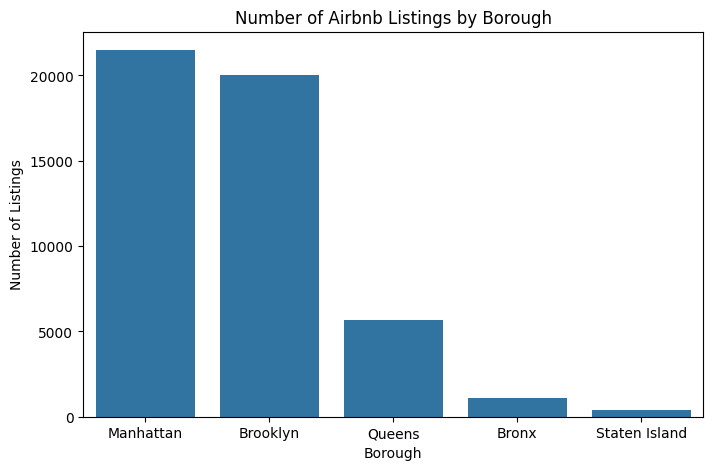

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="neighbourhood_group",
    order=df_clean["neighbourhood_group"].value_counts().index
)

plt.title("Number of Airbnb Listings by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Listings")
plt.savefig(
    "../images/question1.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### Insight

Manhattan and Brooklyn contain the largest number of Airbnb listings, indicating that these boroughs dominate the New York City short-term rental market.

# Question 2

How do Airbnb listing prices vary across boroughs?

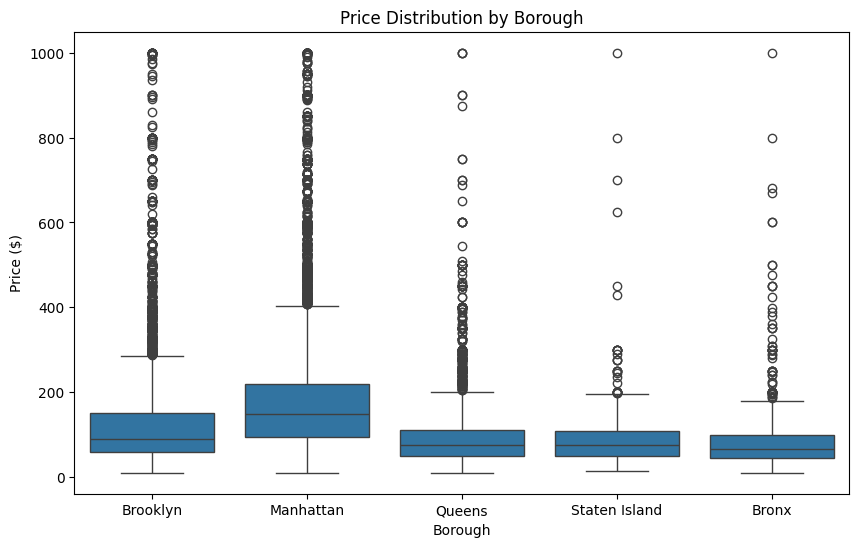

In [28]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x="neighbourhood_group",
    y="price"
)

plt.title("Price Distribution by Borough")
plt.xlabel("Borough")
plt.ylabel("Price ($)")
plt.savefig("../images/question2.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

Manhattan exhibits the highest median prices among all boroughs, indicating stronger revenue potential for property investors. Other boroughs generally show lower pricing levels but may offer lower competition.

# Question 3

How does room type affect Airbnb pricing?

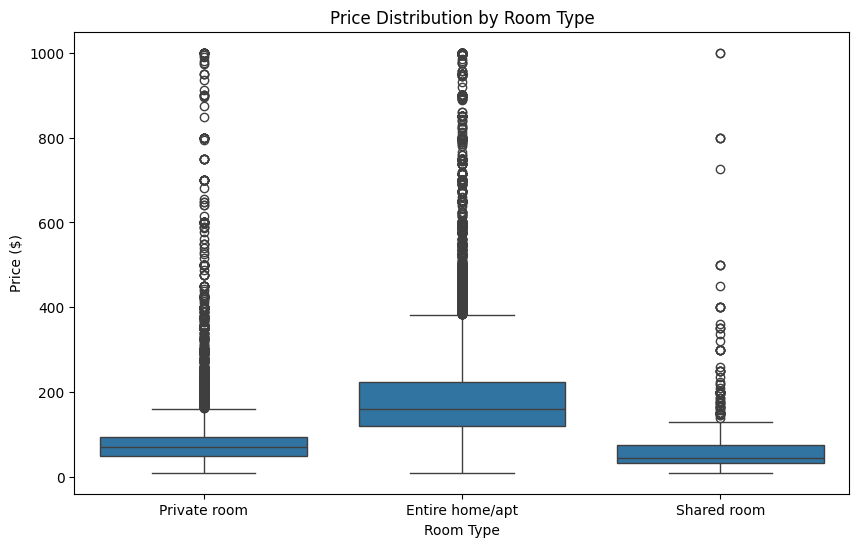

In [29]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x="room_type",
    y="price"
)

plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price ($)")
plt.savefig("../images/question3.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

Entire homes/apartments command significantly higher prices than private rooms and shared rooms. This suggests that investors seeking higher revenue potential may benefit from entire-property rentals.

# Question 4

Which neighborhoods have the highest median Airbnb prices?

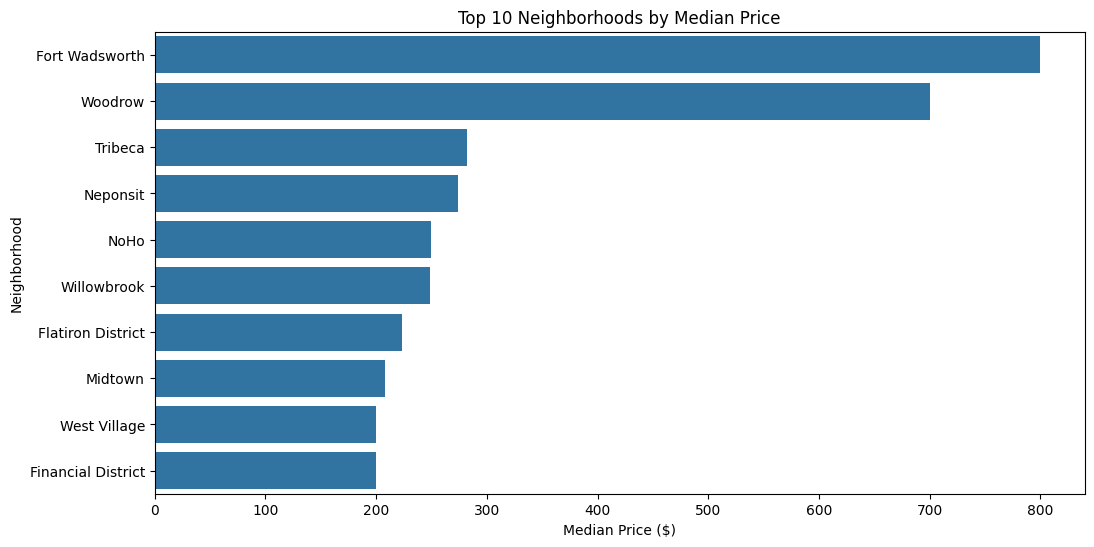

In [30]:
top10 = (
    df_clean.groupby("neighbourhood")["price"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Neighborhoods by Median Price")
plt.xlabel("Median Price ($)")
plt.ylabel("Neighborhood")
plt.savefig("../images/question4.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

A small number of neighborhoods command premium pricing. Investors targeting high-end markets should focus on these locations while considering competition and operating costs.

# Question 5

Which neighborhoods have the highest number of Airbnb listings?

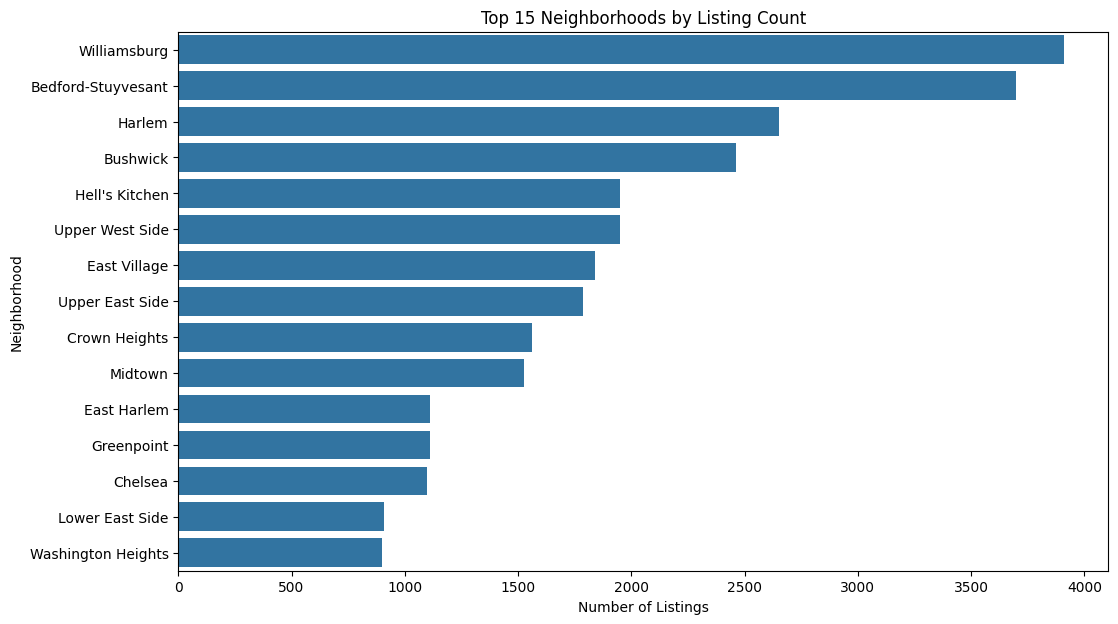

In [31]:
top_supply = (
    df_clean["neighbourhood"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=top_supply.values,
    y=top_supply.index
)

plt.title("Top 15 Neighborhoods by Listing Count")
plt.xlabel("Number of Listings")
plt.ylabel("Neighborhood")
plt.savefig("../images/question5.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

### Insight

These neighborhoods have the highest concentration of Airbnb listings. High listing density may indicate stronger competition among hosts and potential market saturation.|

# Question 6

How do prices vary across boroughs and room types?

In [41]:
fig = px.box(
    df_clean,
    x="neighbourhood_group",
    y="price",
    color="room_type",
    title="Interactive Price Comparison by Borough and Room Type"
)
fig.write_html("../reports/price_analysis.html")
fig.show()

### Insight

The interactive visualization allows stakeholders to explore pricing differences across boroughs and room types in greater detail.

# Question 7

Where are Airbnb listings geographically concentrated across New York City?

In [42]:
sample_df = df_clean.sample(
    n=5000,
    random_state=42
)

fig = px.scatter_map(
    sample_df,
    lat="latitude",
    lon="longitude",
    color="price",
    hover_name="neighbourhood",
    zoom=10,
    title="Geographical Distribution of Airbnb Listings"
)
fig.write_html("../reports/geospatial_map.html")
fig.show()

### Insight

Airbnb listings are heavily concentrated in Manhattan and Brooklyn. Higher-priced listings tend to cluster in central areas, indicating strong location-based pricing effects.

# Investor Recommendations

## Recommendation 1

Focus on neighborhoods that balance strong pricing with moderate competition rather than targeting only the most saturated areas.

## Recommendation 2

Entire-home listings consistently command higher nightly rates and may provide stronger revenue potential.

## Recommendation 3

Location is a major pricing driver. Areas with strong listing density and premium pricing should be prioritized for further investment analysis.

# Limitations

- The dataset represents a single historical snapshot.
- Occupancy rates are unavailable.
- Revenue cannot be estimated directly from listing prices.
- Seasonal demand patterns are not included.
- Some luxury listings were removed during outlier treatment.

# Conclusion

The New York City Airbnb market is dominated by Manhattan and Brooklyn in terms of listing volume. Manhattan generally commands the highest prices, while entire-home listings achieve premium rates compared with private and shared rooms. Location remains the strongest factor influencing pricing, making neighborhood selection critical for investment decisions.